# Parameter estimation

In [13]:
# !pip install diffrax
# !pip install optax

In [14]:
import time
from datetime import datetime
from IPython.display import clear_output

import diffrax
import equinox as eqx  # https://github.com/patrick-kidger/equinox
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import optax  # https://github.com/deepmind/optax
from optax.contrib import reduce_on_plateau as plateau

In [15]:
class Neural_VectorField(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.mlp = eqx.nn.MLP(
            in_size=1,
            out_size=2,
            width_size=width_size,
            depth=depth,
            activation=jnn.softplus,
            final_activation=jnn.sigmoid, # Constrain output to [0, 1] to ensure numerical stability during ODE integration
            key=key,
        )

    def __call__(self, t, y, args=None):
        S, I = y
        S += args
        I += args
        alpha, beta = self.mlp(jnp.array([t]))
        dSdt = -beta * S * I
        dIdt = beta * S * I - alpha * I
        return jnp.array([dSdt, dIdt])

In [27]:
class NeuralODE(eqx.Module):
    vf: Neural_VectorField

    def __init__(self, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.vf = Neural_VectorField(width_size, depth, key=key)

    def __call__(self, ts, y0, eps=0):
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.vf),
            diffrax.Tsit5(),
            t0=0,
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=eps, 
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys
    
    def plot_params(self):
        ts = jnp.linspace(0, 30, 1000)
        ts_input = ts[:, None]

        alphas_betas = jax.vmap(self.vf.mlp)(ts_input)
        alphas = alphas_betas[:, 0]
        betas = alphas_betas[:, 1]

        plt.plot(ts, alphas, label='alpha(t)')
        plt.plot(ts, betas, label='beta(t)')
        plt.title("Alpha(t) and Beta(t) over Time")
        plt.xlabel("Time t")
        plt.ylabel("Value")
        plt.legend()
        plt.show()

In [28]:
class VectorField(eqx.Module):
    def beta(self, t):
        return 0.025
        beta = lambda t: 0.025 * jnp.sin(2 * jnp.pi * t / 30) + 0.03
        return beta(t)

    def alpha(self, t):
        return 0.2

    def __call__(self, t, y, args=None):
        S, I = y
        beta = self.beta(t)
        alpha = self.alpha(t)
        dSdt = -beta * S * I
        dIdt = beta * S * I - alpha * I
        return jnp.array([dSdt, dIdt])

    def simulate(self, ts=None, y0=jnp.array([100., 1.])):
        if ts is None:
            ts = jnp.linspace(0.0, 30.0, 1000)

        def f(t, y, args=None):
            return self(t, y)

        sol = diffrax.diffeqsolve(
            diffrax.ODETerm(f),
            solver=diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=0.1,
            y0=y0,
            saveat=diffrax.SaveAt(ts=ts),
        )

        return ts, sol.ys

    def simulate_and_plot(self, flag):
        ts, ys = self.simulate()
        S, I = ys[:, 0], ys[:, 1]
        if flag:
            S += self.eps
            I += self.eps

        plt.figure(figsize=(10, 5))
        plt.plot(ts, S, label="Susceptible S(t)")
        plt.plot(ts, I, label="Infected I(t)")
        plt.title("SIR Simulation using VectorField")
        plt.xlabel("Time t")
        plt.ylabel("Population")
        plt.legend()
        plt.show()

    def plot_params(self):
        ts = jnp.linspace(0.0, 30.0, 1000)
        alphas = jax.vmap(self.alpha)(ts)
        betas = jax.vmap(self.beta)(ts)

        plt.figure(figsize=(10, 5))
        plt.plot(ts, betas, label="beta(t)")
        plt.plot(ts, alphas, label="alpha(t)")
        plt.title("Time-varying Parameters: beta(t) and alpha(t)")
        plt.xlabel("Time t")
        plt.ylabel("Value")
        plt.legend()
        plt.show()

In [29]:
def _get_data(ts, vf: VectorField, *, key):
    y0 = jnp.array([100., 1.])
    
    _, ys = vf.simulate(ts=ts, y0=y0)
    return ys

# Returns ys with shape (dataset_size, len(ts), 2), where 2 represents the values for S and I.
def get_data(dataset_size, ts=None, *, key, vf=None):
    ts = jnp.concatenate([jnp.array([0.0]), jnp.linspace(0.1, 30, 100)]) if ts is None else ts
    keys = jr.split(key, dataset_size)
    vf = vf or VectorField()
    ys = jax.vmap(lambda k: _get_data(ts, vf, key=k))(keys)
    return ts, ys


In [30]:
# Returns data of size dataset_size in the form of mini-batches. Note that we treat the 1,000 time points in ts as a single data sample.
def dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    assert dataset_size >= batch_size
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [31]:
def relative_error(pred, true):
    assert(pred.shape == true.shape)
    
    if pred.ndim == 0:  # Scalar case
        return jnp.abs(pred - true) / jnp.abs(true)
    else:  # Vector (or higher-dimension) case
        return jnp.linalg.norm(pred - true, 2) / jnp.linalg.norm(true, 2)
    
def get_experiment_id():
    return datetime.now().strftime("%Y%m%d%H%M%S%f")

In [67]:
def main(
    dataset_size=256,
    batch_size=1,
    lr=3e-3,
    steps_strategy=(10000, 10000),
    length_strategy=(1, 1),
    width_size=64,
    depth=2,
    seed=5678,
    plot=True,
    print_every=100,
    sampling_strategy = None,
    eps = 1e-3
):
    key = jr.PRNGKey(seed)
    data_key, model_key, loader_key = jr.split(key, 3)

    ts, ys = get_data(dataset_size, ts=sampling_strategy, key=data_key)
    _, length_size, _ = ys.shape

    model = NeuralODE(width_size, depth, key=model_key)
    # optim = optax.adabelief(lr) provides better performance in general cases. 
    # When training a model to learn the initial conditions of S and I as parameters (while keeping the parameters in the differential equation fixed), it tends to perform better.
    # optim = optax.adam(lr)
    optim = optax.chain(
            optax.adam(lr),
            plateau(patience=1000, accumulation_size=2)
    )   

    # Training loop like normal.
    #
    # Only thing to notice is that up until step 500 we train on only the first 10% of
    # each time series. This is a standard trick to avoid getting caught in a local
    # minimum.

    @eqx.filter_value_and_grad
    def grad_loss(model, ti, yi, flag):
        y_pred = jax.vmap(model, in_axes=(None, 0, None))(ti, yi[:, 0], eps)  # ys.shape = (dataset_dize, len(ts), 2)
        return jnp.mean((yi - y_pred) ** 2)

    @eqx.filter_jit
    def make_step(ti, yi, model, opt_state, flag):
        loss, grads = grad_loss(model, ti, yi, flag)
        updates, opt_state = optim.update(grads, opt_state, value=loss)
        model = eqx.apply_updates(model, updates)
        return loss, model, opt_state

    loss_list = []
    for ind, (steps, length) in enumerate(zip(steps_strategy, length_strategy)):
        opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))
        _ts = ts[: int(length_size * length)]
        _ys = ys[:, : int(length_size * length)]
        for step, (yi,) in zip(
            range(steps), dataloader((_ys,), batch_size, key=loader_key)
        ):
            start = time.time()
            loss, model, opt_state = make_step(_ts, yi, model, opt_state, ind==0)
            loss_list.append(loss)
            end = time.time()
            if (step % print_every) == 0 or step == steps - 1:
                print(f"Step: {step}, Loss: {loss}, Computation time: {end - start}, lr scale: {optax.tree.get(opt_state, 'scale')}")
                clear_output(wait=True)

    if plot:
        exact_ts, exact_ys = get_data(1, ts=jnp.linspace(0, 30, 1000), key=data_key)
        model_y = model(exact_ts, exact_ys[0, 0])

        # relative error 계산
        rel_S = relative_error(exact_ys[0, :, 0], model_y[:, 0])
        rel_I = relative_error(exact_ys[0, :, 1], model_y[:, 1])

        # Figure setup
        figure = plt.figure(figsize=(15,5))
        plt.suptitle(f'Results - NeuralODE')

        # Subplot for Susceptible (S)
        ax1 = figure.add_subplot(1,3,1)
        ax1.plot(exact_ts, exact_ys[0, :, 0], color='C0', label="Susceptible")
        ax1.plot(exact_ts, model_y[:, 0], linestyle='--', lw=2, color='C2', label='Trained NN')
        ax1.scatter(ts, ys[0, :, 0], color='red', marker='x', label='Sampled Susceptible', alpha=0.6)
        ax1.set_title(f'S(Relative error: {rel_S:.2e})')
        ax1.set_xlabel('t')
        ax1.legend()

        # Subplot for Infected (I)
        ax2 = figure.add_subplot(1,3,2)
        ax2.plot(exact_ts, exact_ys[0, :, 1], color='C1', label="Infected")
        ax2.plot(exact_ts, model_y[:, 1], linestyle='--', lw=2, color='C3', label='Trained NN')
        ax2.scatter(ts, ys[0, :, 1], color='red', marker='x', label='Sampled Infected', alpha=0.6)
        ax2.set_title(f'I(Relative error: {rel_I:.2e})')
        ax2.set_xlabel('t')
        ax2.legend()

        # Subplot for Training Loss
        ax3 = figure.add_subplot(1,3,3)
        ax3.plot(loss_list, label='loss_total')
        ax3.set_yscale('log')  # y축을 로그 스케일로 변경
        ax3.set_ylim(1e-6, 1e2)  # 적당한 범위로 설정 (필요하면 조정 가능)
        ax3.set_title('loss')
        ax3.set_xlabel('epoch')
        ax3.legend()

        plt.savefig(f"result/neural_ode_{get_experiment_id()}.png")

    return ts, ys, model

In [68]:
def compare(vf: VectorField, model: NeuralODE):
    ts = jnp.linspace(0, 30, 1000)

    # VectorField의 파라미터
    alphas_vf = jax.vmap(vf.alpha)(ts)
    betas_vf = jax.vmap(vf.beta)(ts)

    # NeuralODE의 파라미터
    ts_input = ts[:, None]
    alphas_betas_model = jax.vmap(model.vf.mlp)(ts_input)
    alphas_model = alphas_betas_model[:, 0]
    betas_model = alphas_betas_model[:, 1]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(ts, alphas_vf, label="alpha (VectorField)")
    plt.plot(ts, alphas_model, label="alpha (NeuralODE)", linestyle="--")
    plt.title("Alpha(t) Comparison")
    plt.xlabel("Time t")
    plt.ylabel("Alpha(t)")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(ts, betas_vf, label="beta (VectorField)")
    plt.plot(ts, betas_model, label="beta (NeuralODE)", linestyle="--")
    plt.title("Beta(t) Comparison")
    plt.xlabel("Time t")
    plt.ylabel("Beta(t)")
    plt.legend()

    plt.show()


## Exact params

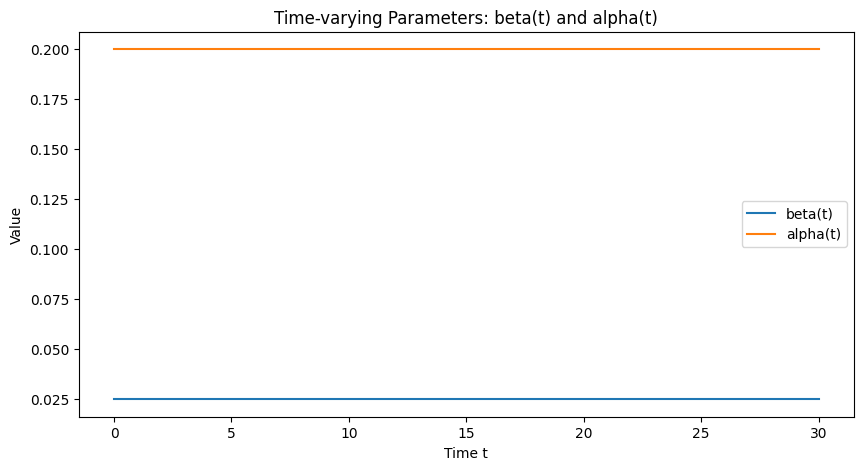

In [69]:
vf = VectorField()
vf.plot_params()

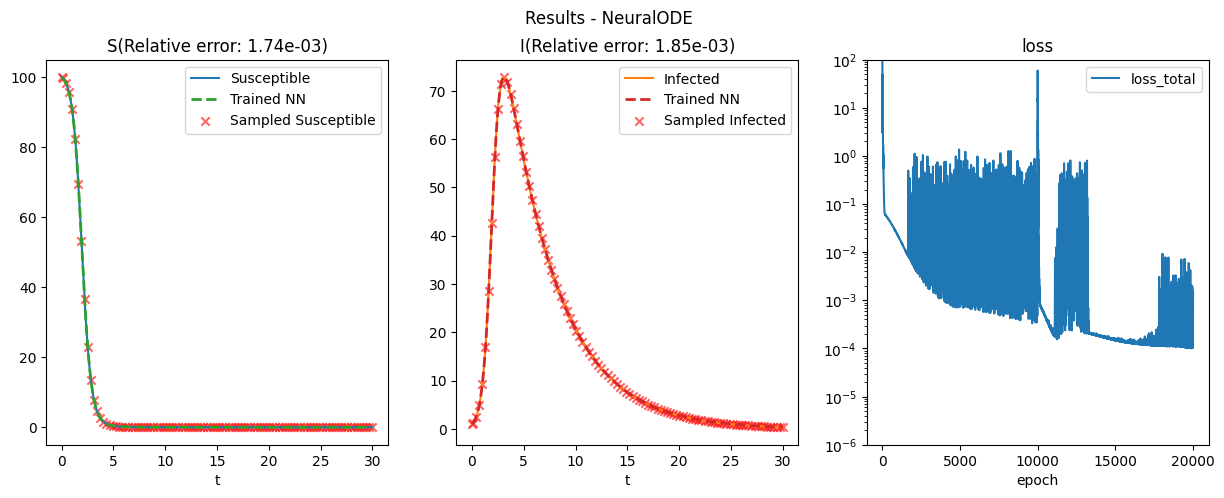

In [70]:
ts, ys, model = main()

## Predicted params

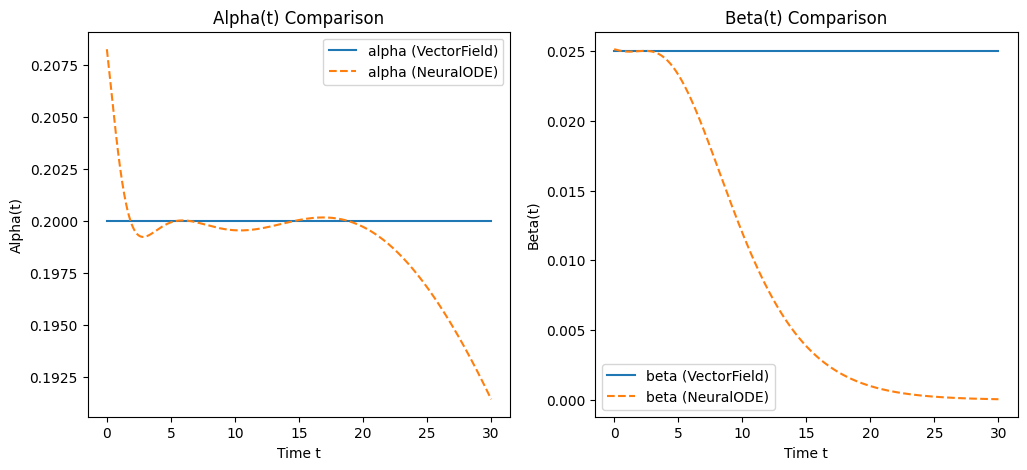

In [71]:
compare(vf, model)

Some notes on speed:
The hyperparameters for the above example haven't really been optimised. Try experimenting with them to see how much faster you can make this example run. There's lots of things you can try tweaking:

- The size of the neural network.
- The numerical solver.
- The step size controller, including both its step size and its tolerances.
- The length of the dataset. (Do you really need to use all of a time series every time?)
- Batch size, learning rate, choice of optimiser.
- ... etc.!

Some notes on being Markov:

- This example has assumed that the problem is Markov. Essentially, that the data `ys` is a complete observation of the system, and that we're not missing any channels. Note how the result of our model is evolving in data space. This is unlike e.g. an RNN, which has hidden state, and a linear map from hidden state to data.
- If we wanted we could generalise this to the non-Markov case: inside `NeuralODE`, project the initial condition into some high-dimensional latent space, do the ODE solve there, then take a linear map to get the output. See the [Latent ODE example](./latent_ode.ipynb) for an example doing this as part of a generative model; also see [Augmented Neural ODEs](https://arxiv.org/abs/1904.01681) for a short paper on it.